<a href="https://colab.research.google.com/github/Ikbal-ullah/JE-Early-Warning-System/blob/master/validatingPhase1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Load the matrix
df = pd.read_csv("nalbari_h3_weather_matrix.csv.gz")

print("--- SYSTEM SANITY CHECK ---")
print(f"Total Rows (Should be ~2.9 million): {len(df)}")
print(f"Unique Hexagons (Should be 2671): {df['hexagon'].nunique()}")
print(f"Missing Values (Must be 0): {df.isnull().sum().sum()}")

# Extreme value validation for Assam (Temp in Celsius, Precip in mm)
print(f"Max Temp Recorded (Expect ~38C): {df['temp_max'].max():.2f}")
print(f"Min Temp Recorded (Expect ~8C): {df['temp_mean'].min():.2f}")
print(f"Max Daily Rain (Expect ~150mm+): {df['precip'].max():.2f}")

--- SYSTEM SANITY CHECK ---
Total Rows (Should be ~2.9 million): 2924745
Unique Hexagons (Should be 2671): 2671
Missing Values (Must be 0): 0
Max Temp Recorded (Expect ~38C): 37.15
Min Temp Recorded (Expect ~8C): 12.40
Max Daily Rain (Expect ~150mm+): 277.92


Loading matrix for visual diagnostic...


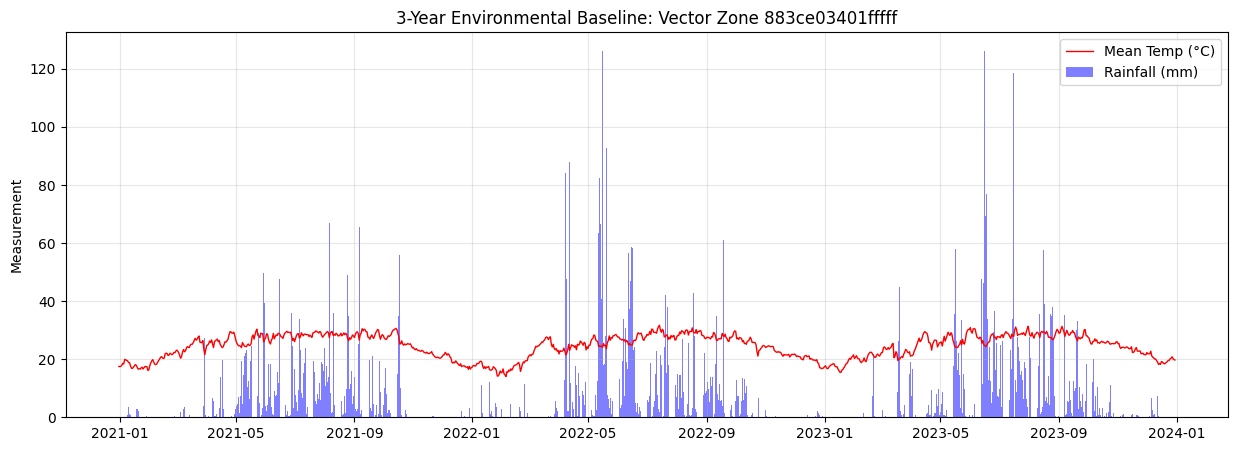

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

print("Loading matrix for visual diagnostic...")
df = pd.read_csv("nalbari_h3_weather_matrix.csv.gz")

# Isolate a single spatial zone
sample_hex = df['hexagon'].iloc[0]
hex_data = df[df['hexagon'] == sample_hex].copy()
hex_data['time'] = pd.to_datetime(hex_data['time'])

# Render the physical environment
plt.figure(figsize=(15, 5))
plt.plot(hex_data['time'], hex_data['temp_mean'], label='Mean Temp (°C)', color='red', linewidth=1)
plt.bar(hex_data['time'], hex_data['precip'], label='Rainfall (mm)', color='blue', alpha=0.5)
plt.title(f"3-Year Environmental Baseline: Vector Zone {sample_hex}")
plt.ylabel("Measurement")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
